In [53]:
#Import libraries

import ee 
import geemap
import xee
import xarray as xr
import datetime
import rioxarray as rxr
import os
import ipyleaflet
import gdown
import rasterio
from rasterio import features
from osgeo import gdal, ogr, osr
import os, glob, re, csv
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import json
import geopandas as gpd
from IPython.display import HTML
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import animation, colors, rc
from matplotlib.animation import FuncAnimation
import matplotlib.dates as mdates
from datetime import datetime
from functools import reduce

import matplotlib.image as mpimg
import matplotlib.animation as animation
from matplotlib.animation import HTMLWriter



Get each id for which csvs have been processed

In [45]:
# run this code to reorganize csv files into folders
import shutil

# get all files matching the pattern "01.XXXXX*"
main_directory = os.getcwd()
csv_fp = main_directory + '/csv/'
rgi_reg = 1 
csv_files = glob.glob(os.path.join(csv_fp, f"{str(rgi_reg).zfill(2)}.[0-9]*.csv"))


# Process each file
for csv_file in csv_files:
    csv_fn = os.path.basename(csv_file)
    glacier_name = csv_fn[:8] # extract glacier name (first 8 characters: "01.XXXXX")

    glac_folder = os.path.join(csv_fp, glacier_name) # create the target directory if it doesn't exist
    os.makedirs(glac_folder, exist_ok=True)

    shutil.move(csv_file, os.path.join(glac_folder, csv_fn)) # move the file to its corresponding glacier folder


--- Glacier 6023 (1 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6023_diff_timeseries.csv


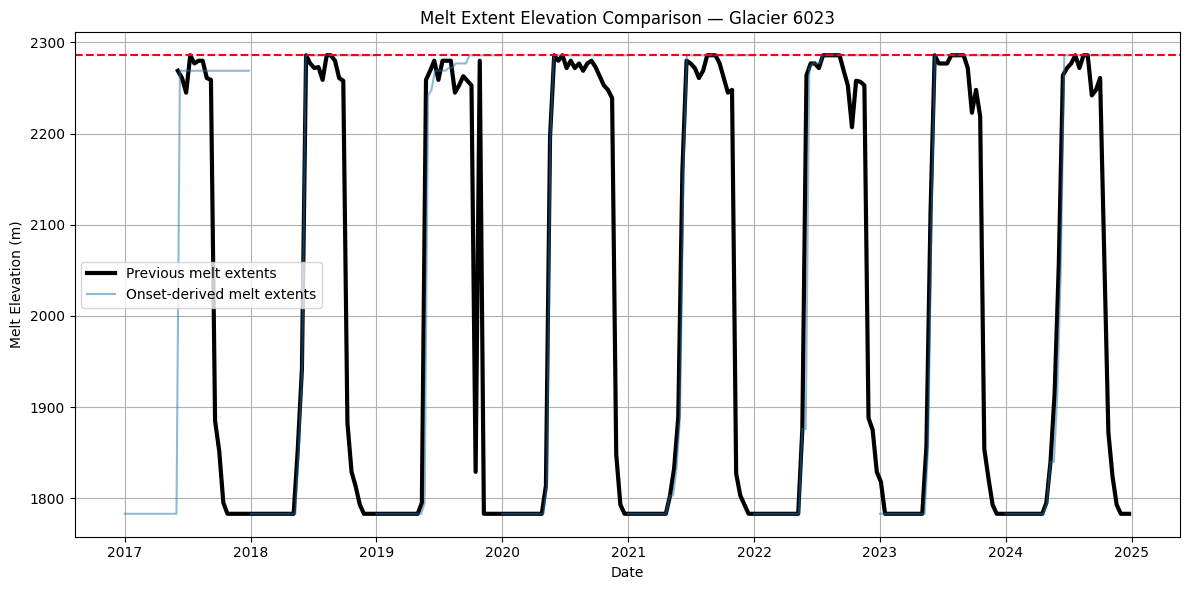


--- Glacier 6025 (2 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6025_diff_timeseries.csv


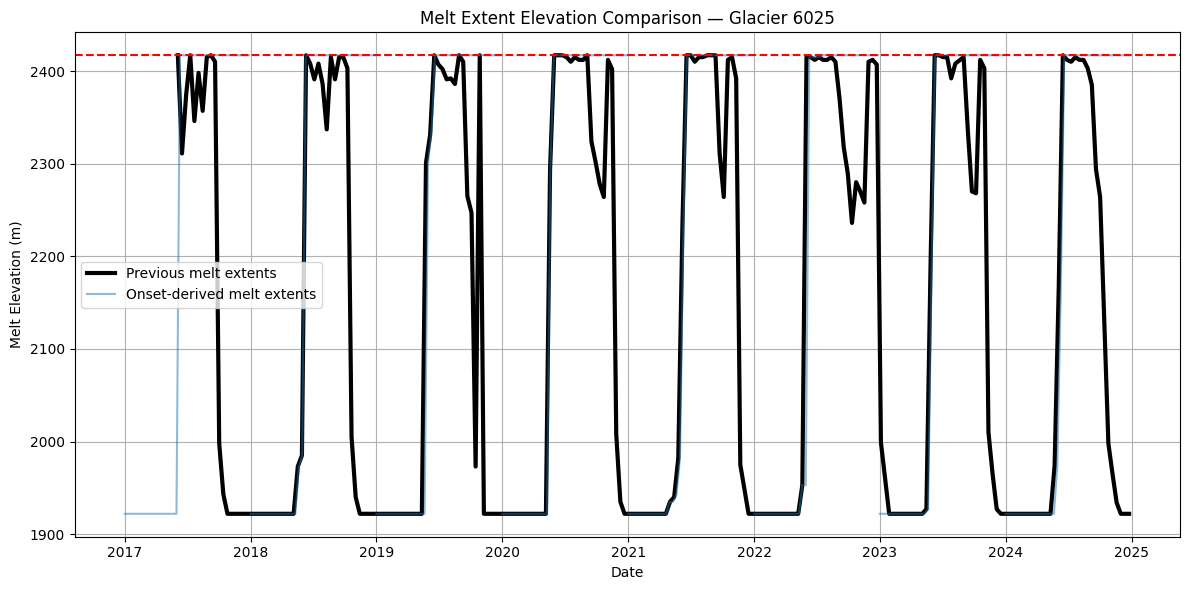


--- Glacier 6026 (3 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6026_diff_timeseries.csv


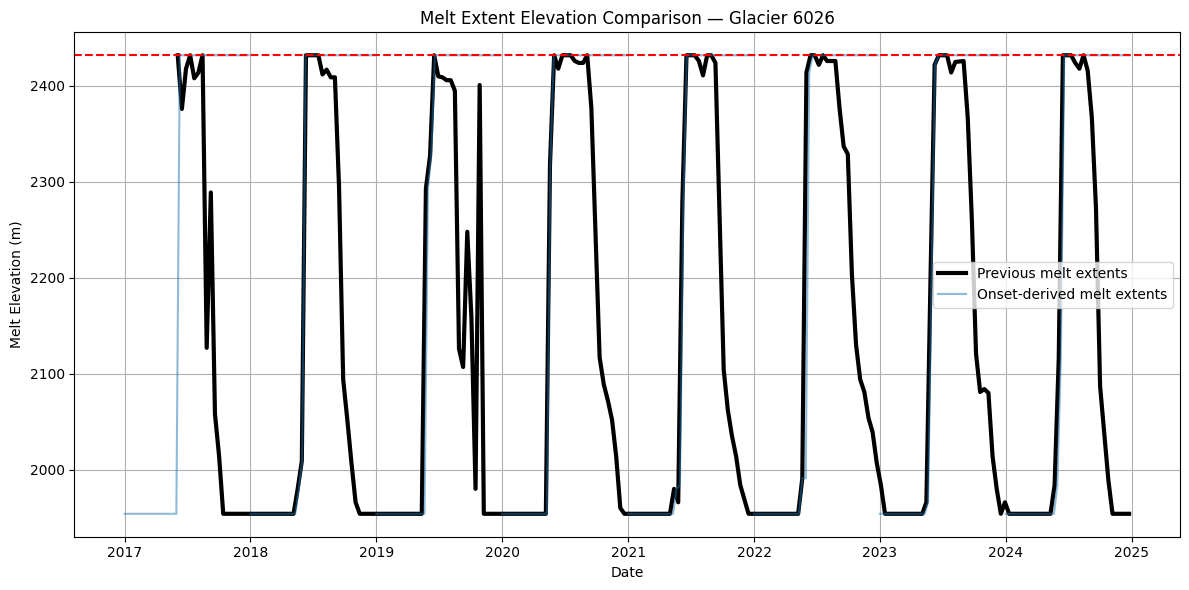


--- Glacier 6029 (4 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6029_diff_timeseries.csv


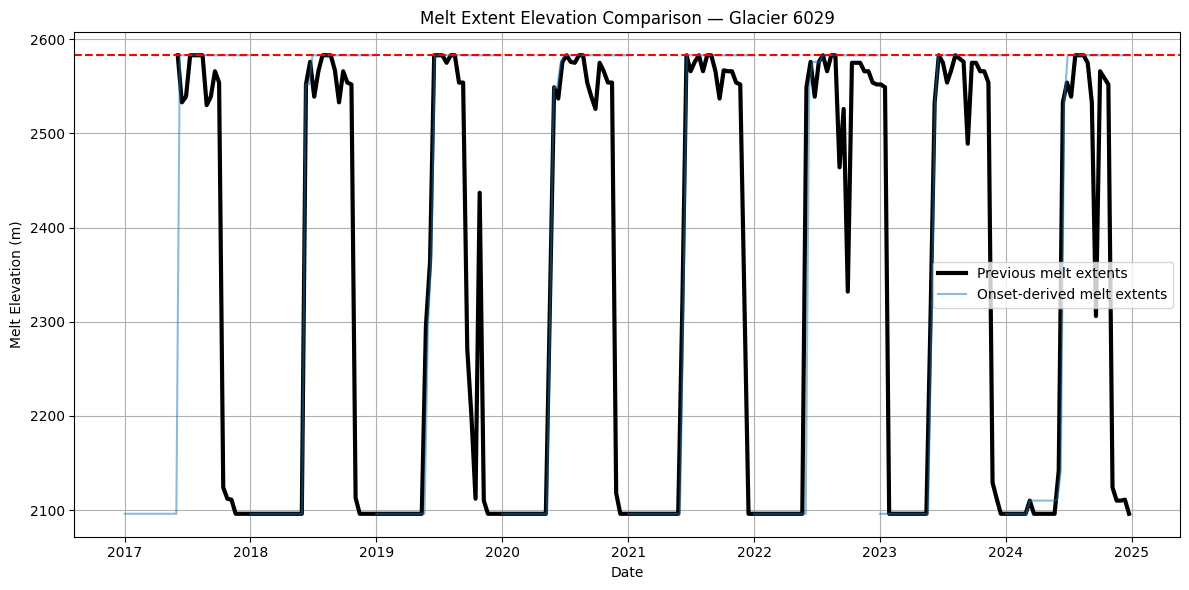


--- Glacier 6031 (5 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6031_diff_timeseries.csv


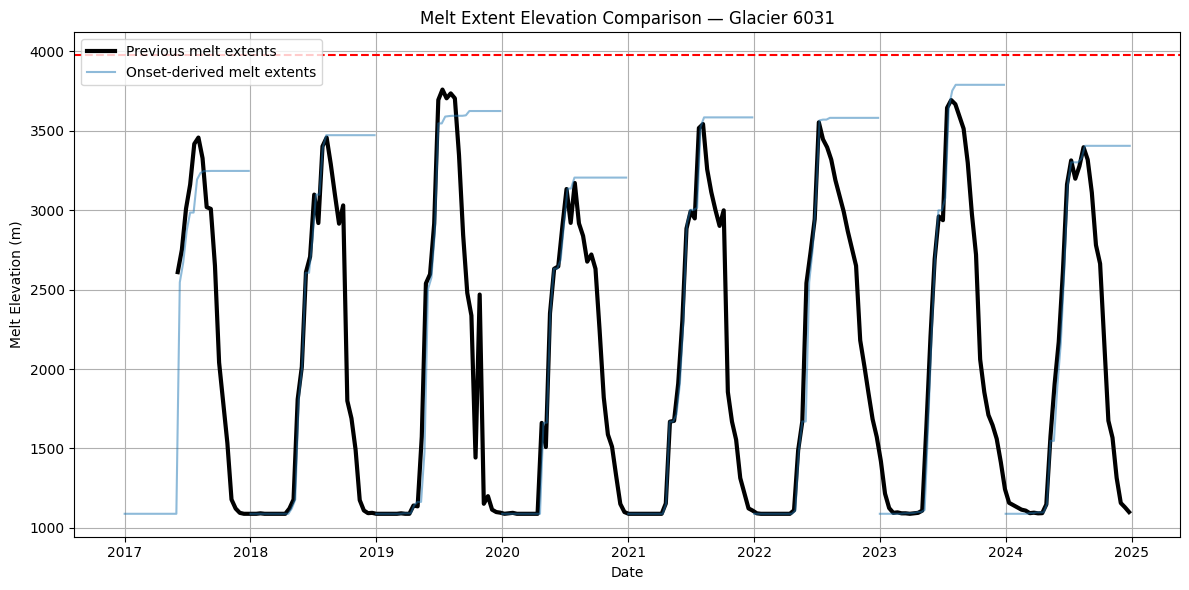


--- Glacier 6043 (6 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6043_diff_timeseries.csv


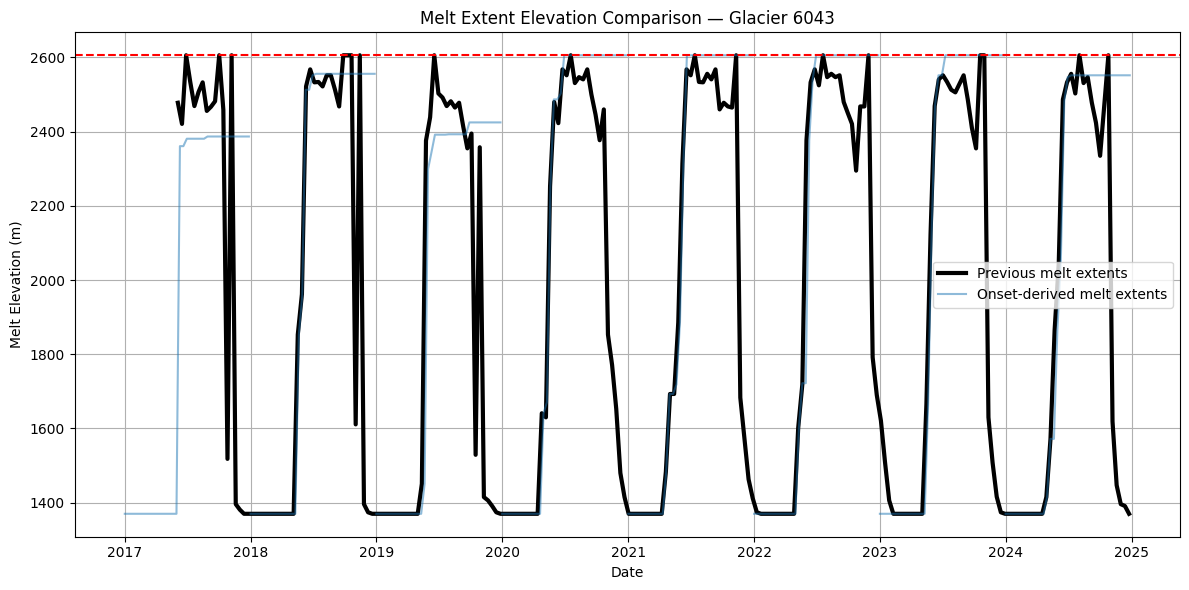


--- Glacier 6047 (7 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6047_diff_timeseries.csv


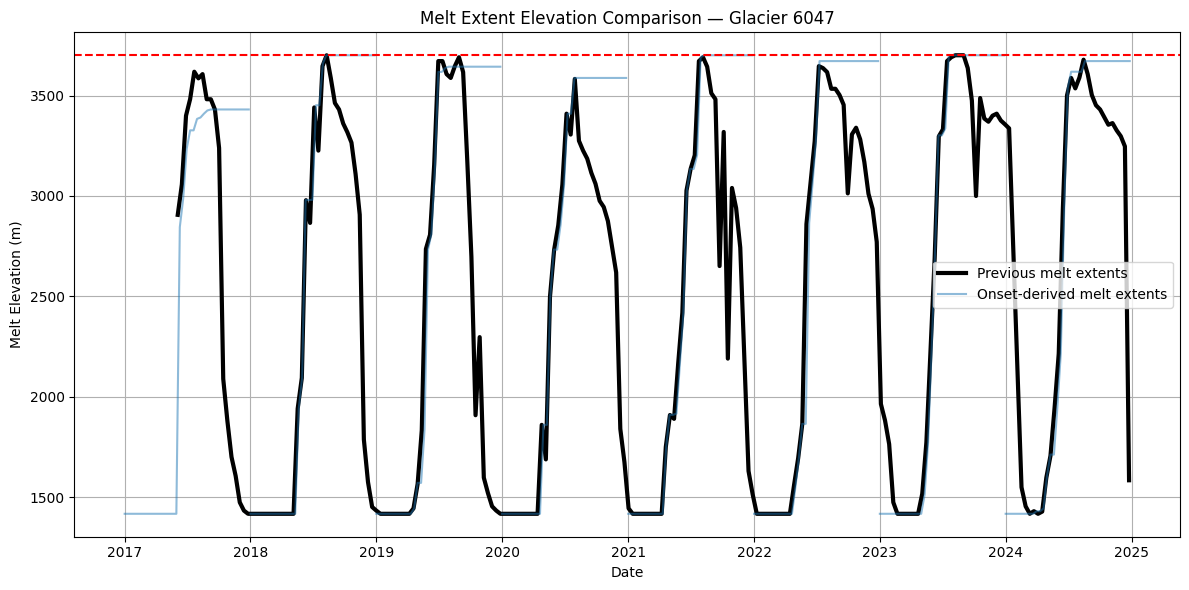


--- Glacier 6352 (8 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6352_diff_timeseries.csv


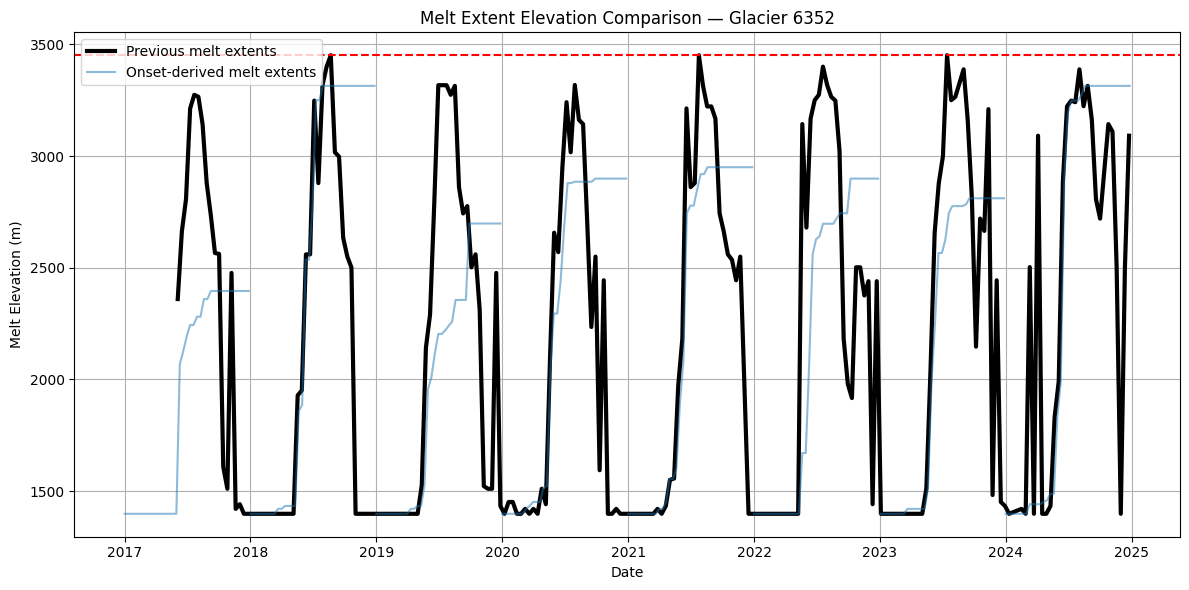


--- Glacier 6353 (9 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6353_diff_timeseries.csv


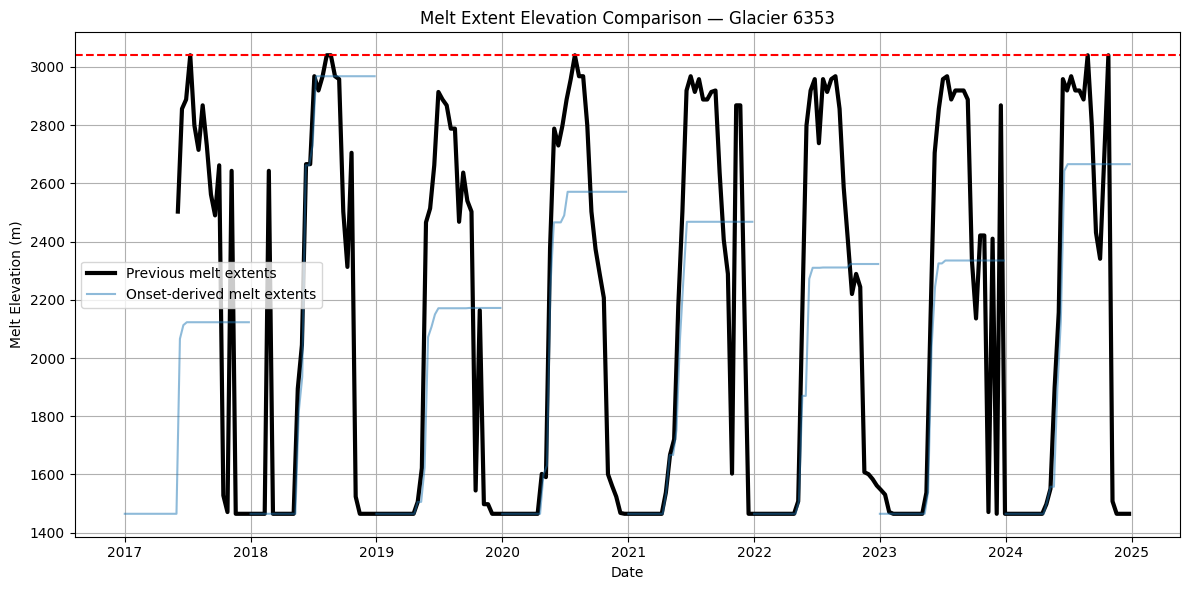


--- Glacier 6360 (10 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6360_diff_timeseries.csv


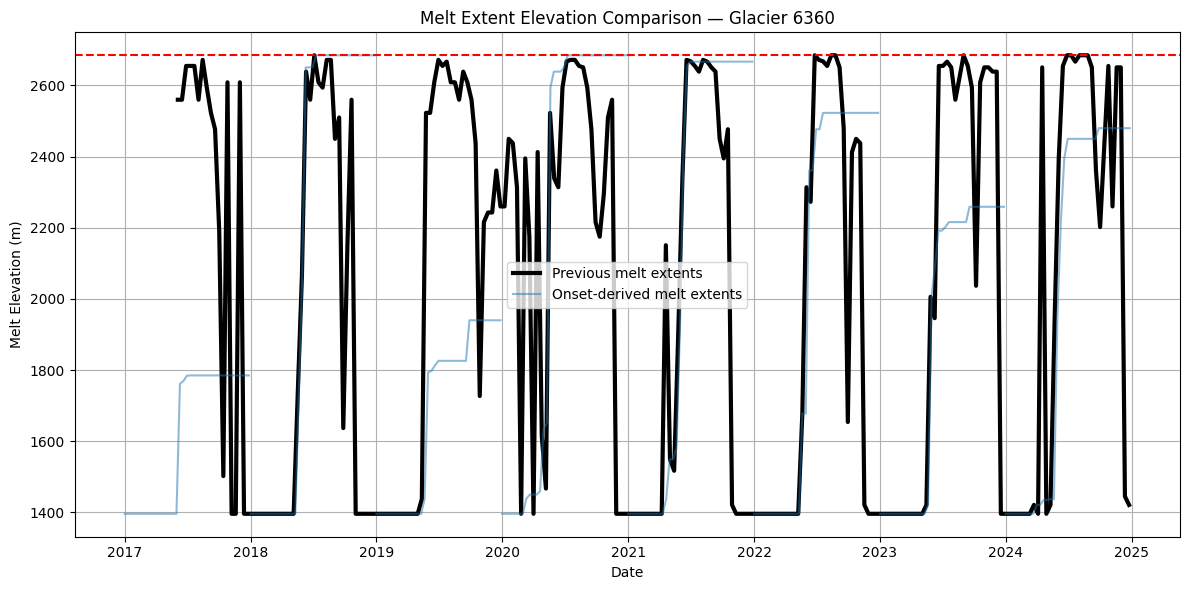


--- Glacier 6369 (11 so far) ---
Saved diff timeseries: c:\Users\jaden\Downloads\Research\onset_maps\csv_differences/6369_diff_timeseries.csv


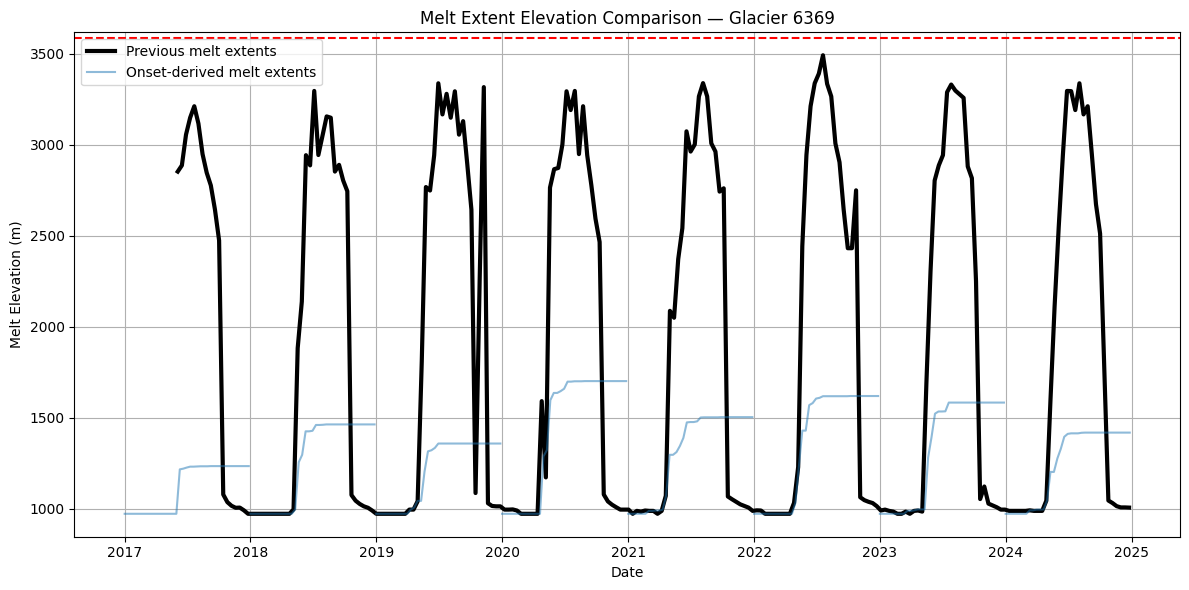

In [61]:
# ----------------------------------------------------
# DIRECTORIES
# ----------------------------------------------------
yearly_dir = r"C:\Users\jaden\Downloads\Research\onset_maps\csv_me_tests"
multi_root = r"C:\Users\jaden\Downloads\Research\onset_maps\csv"

yearly_pattern = re.compile(r"melt_snowline_time_series_(\d+)_(\d{4})\.csv")
multi_pattern = re.compile(r"(\d{2})\.(\d{5})_melt_extent_elev_percentile_.*\.csv")

# Load onset csvs
yearly = {}

for fn in os.listdir(yearly_dir):
    m = yearly_pattern.match(fn)
    if not m:
        continue

    glacnum = int(m.group(1))
    if str(glacnum) not in ['6023', '6025', '6026', '6029', '6031', '6043', '6047', '6352', '6353', '6360', '6369'] : continue #this is for testing 
    year = int(m.group(2))

    df = pd.read_csv(os.path.join(yearly_dir, fn))

    # unify yearly melt column name if needed
    if "melt_extent_elev_m" in df.columns:
        meltcol = "melt_extent_elev_m"
    elif "melt_elev" in df.columns:
        meltcol = "melt_elev"
    else:
        raise ValueError(f"Could not find melt elevation column in yearly file {fn}")

    df["melt_col"] = df[meltcol]
    df["year"] = year
    df["glacier"] = glacnum

    yearly.setdefault(glacnum, {})[year] = df

processed = 0

for folder in sorted(os.listdir(multi_root)):

    folder_path = os.path.join(multi_root, folder)
    if not os.path.isdir(folder_path):
        continue

    # Folder name like "01.05525"
    if not re.match(r"\d{2}\.\d{5}", folder):
        continue

    region, glac_str = folder.split(".")
    glacnum = int(glac_str)

    if glacnum not in yearly:
        continue

    # if processed >= 10:
    #     break

    processed += 1
    print(f"\n--- Glacier {glacnum} ({processed} so far) ---")

    
    multi_file = None
    for fn in os.listdir(folder_path):
        m = multi_pattern.match(fn)
        if m and int(m.group(2)) == glacnum:
            multi_file = os.path.join(folder_path, fn)
            break

    if multi_file is None:
        print(f"No multi-year melt extent file for glacier {glacnum}")
        continue

    df_multi = pd.read_csv(multi_file, index_col=0)
    df_multi.index = pd.to_datetime(df_multi.index)
    df_multi["date"] = df_multi.index
    df_multi["year"] = df_multi["date"].dt.year

    if "melt_extent_elev_m" not in df_multi.columns:
        raise ValueError("Multi-year CSV missing melt_extent_elev_m")

    #plot
    years = sorted(yearly[glacnum].keys())
    df_multi_sub = df_multi[df_multi["year"].isin(years)]

    plt.figure(figsize=(12, 6))
    plt.title(f"Melt Extent Elevation Comparison — Glacier {glacnum}")

    # multi-year thick line
    plt.plot(
        df_multi_sub["date"],
        df_multi_sub["melt_extent_elev_m"],
        color="black",
        linewidth=3,
        label="Previous melt extents"
    )

    diff_dfs = []
    # each yearly CSV
    max_elev = None
    for yr in years:
        df_y = yearly[glacnum][yr].copy()

        # ------------------------------
        # Ensure onset dates are datetime
        # ------------------------------
        if "date" in df_y.columns:
            df_y["date"] = pd.to_datetime(df_y["date"], errors="coerce")
        elif "doy" in df_y.columns:
            df_y["date"] = pd.to_datetime(df_y["doy"], unit="D", origin=f"{yr}-01-01")
        else:
            raise ValueError(f"Yearly file for {glacnum}, {yr} missing date/doy column")
        
        if max_elev == None:
            if "glacier_max_elev_m" in df_y.columns:
                # Get first non-NaN value safely
                first_val = df_y["glacier_max_elev_m"].dropna().iloc[0]
                max_elev = first_val
            else:
                raise ValueError(f"Yearly file for {glacnum}, {yr} missing max_elev")
        # grab as a series for plotting
        x = df_y["date"]

        # ------------------------------
        # Subset multi-year data to this year
        # ------------------------------
        df_multi_year = df_multi_sub[df_multi_sub["year"] == yr].copy()
        if df_multi_year.empty:
            print(f"  No multi-year data for glacier {glacnum}, year {yr}")
            continue

        df_multi_year["date"] = pd.to_datetime(df_multi_year["date"], errors="coerce")
        df_multi_year = df_multi_year.sort_values("date")

        # ------------------------------
        # Build a time-indexed series and interpolate
        # ------------------------------
        prev_series = df_multi_year.set_index("date")["melt_extent_elev_m"]

        # union of all dates (prev + onset) to allow interpolation
        all_idx = prev_series.index.union(df_y["date"])
        prev_interp = (
            prev_series
            .reindex(all_idx)
            .interpolate(method="time")  # uses neighboring timestamps
        )

        # ------------------------------
        # Build merged frame on *onset* dates
        # ------------------------------
        merged = df_y[["date", "melt_col"]].copy()
        # look up interpolated previous melt on these dates
        merged["melt_extent_elev_m"] = prev_interp.loc[merged["date"].values].values

        # Add metadata
        merged["year"] = yr
        merged["glacier"] = glacnum

        # Difference: onset - interpolated previous
        merged["diff_onset_minus_prev_m"] = (
            merged["melt_col"] - merged["melt_extent_elev_m"]
        )

        diff_dfs.append(merged)

        # plot onset curve as before
        plt.plot(
            x,
            df_y["melt_col"],
            color="tab:blue",
            alpha=0.5,
            label="Onset-derived melt extents"
        )


    # concatenate all years for this glacier and save
    if diff_dfs:
        out_dir = os.path.join(os.getcwd(), 'csv_differences/')
        os.makedirs(out_dir, exist_ok=True)

        diff_all = pd.concat(diff_dfs, ignore_index=True)
        diff_csv_path = os.path.join(out_dir, f"{glacnum}_diff_timeseries.csv")
        diff_all.rename(
            columns={
                "melt_col": "onset_melt_extent_m",
                "melt_extent_elev_m": "previous_melt_extent_m",
            },
            inplace=True,
        )
        diff_all.to_csv(diff_csv_path, index=False)
        print(f"Saved diff timeseries: {diff_csv_path}")
    else:
        print(f"No overlapping / interpolatable data for glacier {glacnum}; no diff CSV written.")


    plt.xlabel("Date")
    plt.ylabel("Melt Elevation (m)")
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))   # removes duplicate labels
    plt.axhline(max_elev, color="red", linestyle="--", linewidth=1.5, label="Max Glacier Elevation") #max elev ref line
    plt.legend(unique.values(), unique.keys())
    #plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt_dir = os.path.join(os.getcwd(), f'me_cmp_figs\\{glacnum}_comp_fip.png')
    plt.savefig(plt_dir, dpi=100)
    plt.show()

## Compare snowlines



--- Glacier 6025 (1 so far) ---


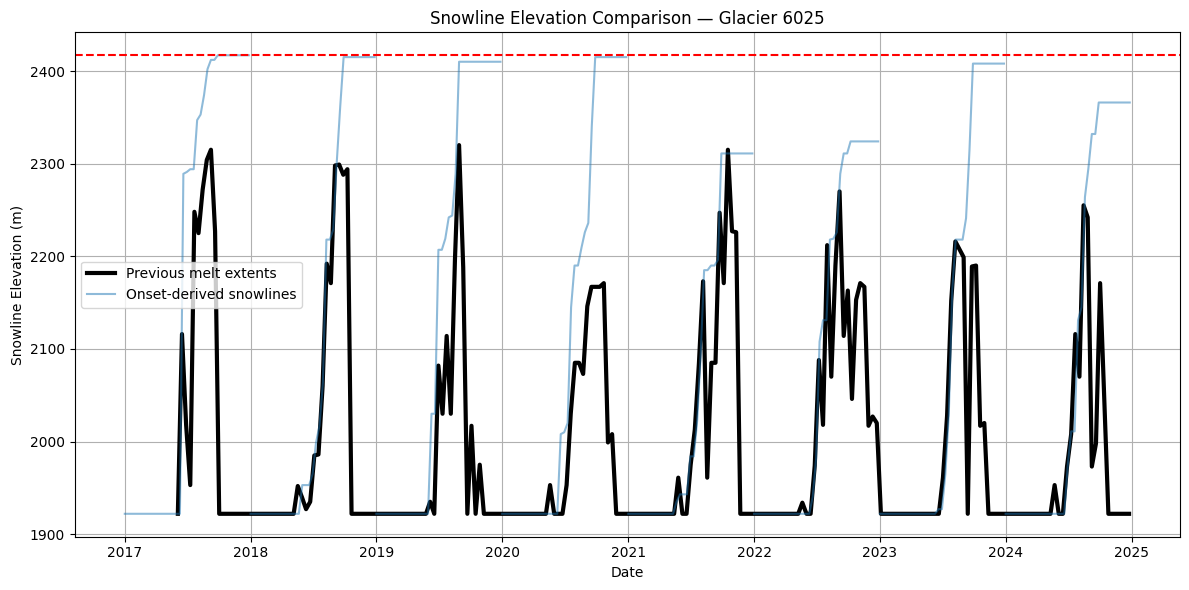

In [52]:
# ----------------------------------------------------
# DIRECTORIES
# ----------------------------------------------------
yearly_dir = r"C:\Users\jaden\Downloads\Research\onset_maps\csv_me_tests"
multi_root = r"C:\Users\jaden\Downloads\Research\onset_maps\csv"

yearly_pattern = re.compile(r"melt_snowline_time_series_(\d+)_(\d{4})\.csv")
multi_pattern = re.compile(r"(\d{2})\.(\d{5})_snowline_elev_percentile_.*\.csv")

# Load onset csvs
yearly = {}

for fn in os.listdir(yearly_dir):
    m = yearly_pattern.match(fn)
    if not m:
        continue

    glacnum = int(m.group(1))
    year = int(m.group(2))

    df = pd.read_csv(os.path.join(yearly_dir, fn))

    snowcol = "snowline_elev_m"

    df["snow_col"] = df[snowcol]
    df["year"] = year
    df["glacier"] = glacnum

    yearly.setdefault(glacnum, {})[year] = df

processed = 0

for folder in sorted(os.listdir(multi_root)):

    folder_path = os.path.join(multi_root, folder)
    if not os.path.isdir(folder_path):
        continue

    # Folder name like "01.05525"
    if not re.match(r"\d{2}\.\d{5}", folder):
        continue

    region, glac_str = folder.split(".")
    glacnum = int(glac_str)

    if glacnum not in yearly:
        continue

    # if processed >= 10:
    #     break

    processed += 1
    print(f"\n--- Glacier {glacnum} ({processed} so far) ---")

    
    multi_file = None
    for fn in os.listdir(folder_path):
        m = multi_pattern.match(fn)
        if m and int(m.group(2)) == glacnum:
            multi_file = os.path.join(folder_path, fn)
            break

    if multi_file is None:
        print(f"No multi-year file for glacier {glacnum}")
        continue

    df_multi = pd.read_csv(multi_file, index_col=0)
    df_multi.index = pd.to_datetime(df_multi.index)
    df_multi["date"] = df_multi.index
    df_multi["year"] = df_multi["date"].dt.year

    if "snowline_elev_m" not in df_multi.columns:
        raise ValueError("Multi-year CSV missing snowline_elev_m")

    #plot
    years = sorted(yearly[glacnum].keys())
    df_multi_sub = df_multi[df_multi["year"].isin(years)]

    plt.figure(figsize=(12, 6))
    plt.title(f"Snowline Elevation Comparison — Glacier {glacnum}")

    # multi-year thick line
    plt.plot(
        df_multi_sub["date"],
        df_multi_sub["snowline_elev_m"],
        color="black",
        linewidth=3,
        label="Previous melt extents"
    )

    diff_dfs = []
    max_elev = None
    # each yearly CSV
    for yr in years:
        df_y = yearly[glacnum][yr].copy()

        # ------------------------------
        # Ensure onset dates are datetime
        # ------------------------------
        if "date" in df_y.columns:
            df_y["date"] = pd.to_datetime(df_y["date"], errors="coerce")
        elif "doy" in df_y.columns:
            df_y["date"] = pd.to_datetime(df_y["doy"], unit="D", origin=f"{yr}-01-01")
        else:
            raise ValueError(f"Yearly file for {glacnum}, {yr} missing date/doy column")

        if max_elev == None:
            if "glacier_max_elev_m" in df_y.columns:
                # Get first non-NaN value safely
                first_val = df_y["glacier_max_elev_m"].dropna().iloc[0]
                max_elev = first_val
            else:
                raise ValueError(f"Yearly file for {glacnum}, {yr} missing max_elev")

        # grab as a series for plotting
        x = df_y["date"]

        # ------------------------------
        # Subset multi-year data to this year
        # ------------------------------
        df_multi_year = df_multi_sub[df_multi_sub["year"] == yr].copy()
        if df_multi_year.empty:
            print(f"  No multi-year data for glacier {glacnum}, year {yr}")
            continue

        df_multi_year["date"] = pd.to_datetime(df_multi_year["date"], errors="coerce")
        df_multi_year = df_multi_year.sort_values("date")

        # ------------------------------
        # Build a time-indexed series and interpolate
        # ------------------------------
        prev_series = df_multi_year.set_index("date")["snowline_elev_m"]

        # union of all dates (prev + onset) to allow interpolation
        all_idx = prev_series.index.union(df_y["date"])
        prev_interp = (
            prev_series
            .reindex(all_idx)
            .interpolate(method="time")  # uses neighboring timestamps
        )

        # ------------------------------
        # Build merged frame on *onset* dates
        # ------------------------------
        merged = df_y[["date", "snow_col"]].copy()
        # look up interpolated previous melt on these dates
        merged["snowline_elev_m"] = prev_interp.loc[merged["date"].values].values

        # Add metadata
        merged["year"] = yr
        merged["glacier"] = glacnum

        # Difference: onset - interpolated previous
        merged["diff_onset_minus_prev_m"] = (
            merged["snow_col"] - merged["snowline_elev_m"]
        )

        diff_dfs.append(merged)

        # plot onset curve as before
        plt.plot(
            x,
            df_y["snow_col"],
            color="tab:blue",
            alpha=0.5,
            label="Onset-derived snowlines"
        )


    # concatenate all years for this glacier and save
    # if diff_dfs:
    #     out_dir = os.path.join(os.getcwd(), 'csv_differences/')
    #     os.makedirs(out_dir, exist_ok=True)

    #     diff_all = pd.concat(diff_dfs, ignore_index=True)
    #     diff_csv_path = os.path.join(out_dir, f"{glacnum}_diff_timeseries.csv")
    #     diff_all.rename(
    #         columns={
    #             "melt_col": "onset_melt_extent_m",
    #             "melt_extent_elev_m": "previous_melt_extent_m",
    #         },
    #         inplace=True,
    #     )
    #     diff_all.to_csv(diff_csv_path, index=False)
    #     print(f"Saved diff timeseries: {diff_csv_path}")
    # else:
    #     print(f"No overlapping / interpolatable data for glacier {glacnum}; no diff CSV written.")


    plt.xlabel("Date")
    plt.ylabel("Snowline Elevation (m)")
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))   # removes duplicate labels
    plt.axhline(max_elev, color="red", linestyle="--", linewidth=1.5, label="Max Glacier Elevation") #max elev ref line
    plt.legend(unique.values(), unique.keys())
    plt.grid(True)
    plt.tight_layout()

    plt_dir = os.path.join(os.getcwd(), f'me_cmp_figs\\{glacnum}_sl_comp_fip.png')
    plt.savefig(plt_dir, dpi=100)
    plt.show()

Found 138 diff files.


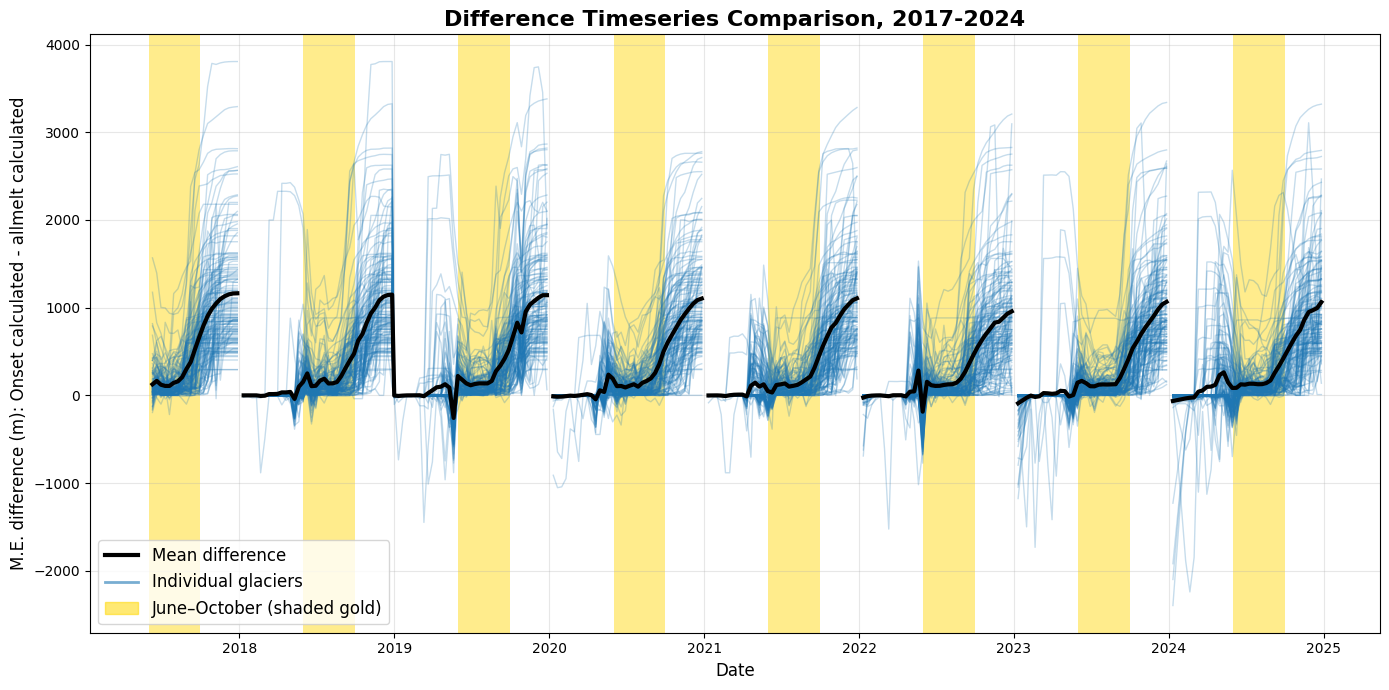

In [44]:
# Directory with *_diff_timeseries.csv files
diff_dir = r"C:\Users\jaden\Downloads\Research\onset_maps\csv_differences"

# Collect files
diff_files = sorted(
    [os.path.join(diff_dir, f) for f in os.listdir(diff_dir) if f.endswith("_diff_timeseries.csv")]
)

print(f"Found {len(diff_files)} diff files.")

# Load all CSVs and rename diff column by glacier number
dfs = []
for fn in diff_files:
    df = pd.read_csv(fn)

    # convert date
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # rename melt difference column using glacier number prefix
    glacnum = os.path.basename(fn).split("_")[0]
    df = df[["date", "diff_onset_minus_prev_m"]].rename(
        columns={"diff_onset_minus_prev_m": glacnum}
    )

    dfs.append(df)

# ----------------------------------------------------------
# OUTER MERGE: union of all dates → full time span
# ----------------------------------------------------------
df_merged = reduce(
    lambda left, right: pd.merge(left, right, on="date", how="outer"),
    dfs
)

df_merged = df_merged.sort_values("date")

# Glacier columns
glacier_cols = df_merged.columns[df_merged.columns != "date"]

# Compute the mean across all glaciers, skipping NaNs
df_merged["mean_diff"] = df_merged[glacier_cols].mean(axis=1, skipna=True)

plt.figure(figsize=(14, 7))
plt.title("Difference Timeseries Comparison, 2017-2024",
          fontsize=16, fontweight="bold")

# ----------------------------------------------------------
# SHADE SUMMER MONTHS (June 1 – October 1 for each year)
# ----------------------------------------------------------
years = df_merged["date"].dt.year.unique()

for yr in years:
    start = pd.Timestamp(f"{yr}-06-01")
    end   = pd.Timestamp(f"{yr}-10-01")

    # Check overlap with actual data range
    data_min, data_max = df_merged["date"].min(), df_merged["date"].max()
    if end < data_min or start > data_max:
        continue

    plt.axvspan(
        start,
        end,
        color="gold",
        alpha=0.45,   # keep subtle
        linewidth=0
    )

# ----------------------------------------------------------
# PLOT LINES
# ----------------------------------------------------------
for col in glacier_cols:
    plt.plot(
        df_merged["date"],
        df_merged[col],
        alpha=0.25,
        linewidth=1,
        color="tab:blue"
    )

plt.plot(
    df_merged["date"],
    df_merged["mean_diff"],
    color="black",
    linewidth=3,
    label="Mean difference (onset - previous)"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("M.E. difference (m): Onset calculated - allmelt calculated", fontsize=12)
plt.grid(True, alpha=0.3)
# Legend items
mean_handle = plt.Line2D(
    [], [], color="black", linewidth=3, label="Mean difference"
)

individual_handle = plt.Line2D(
    [], [], color="tab:blue", linewidth=2, alpha=0.6, label="Individual glaciers"
)

summer_handle = mpatches.Patch(
    color="gold", alpha=0.55, label="June–October (shaded gold)"
)

plt.legend(
    handles=[mean_handle, individual_handle, summer_handle],
    labels=["Mean difference", "Individual glaciers", "June–October (shaded gold)"],
    fontsize=12
)
plt.tight_layout()
plt.show()


### Animate onset graphs

In [54]:
def make_onset_animation_from_pngs(
    img_dir,
    year,
    out_html=None,
    fps=3
):
    """
    Build an HTML animation from PNGs named like:
        onset_map_<year>_doy###.png

    Parameters
    ----------
    img_dir : str
        Directory containing the PNG frames.
    year : int
        Year to match in filenames (e.g., 2024).
    out_html : str or None
        Output HTML path. If None, saves as
        onset_animation_<year>.html in img_dir.
    fps : int
        Frames per second for the animation.
    """

    # Regex to match files like onset_map_2024_doy281.png
    pattern = re.compile(rf"onset_map_{year}_doy(\d+)\.png")

    frames = []
    for fn in os.listdir(img_dir):
        m = pattern.match(fn)
        if m:
            doy = int(m.group(1))
            full_path = os.path.join(img_dir, fn)
            frames.append((doy, full_path))

    if not frames:
        print(f"No matching onset_map_{year}_doyXXX.png files found in {img_dir}")
        return

    # Sort frames by DOY
    frames.sort(key=lambda x: x[0])
    doys = [d for d, _ in frames]
    paths = [p for _, p in frames]

    print(f"Found {len(paths)} frames for year {year}: DOYs {doys[0]}–{doys[-1]}")

    # Load first image to set up figure
    first_img = mpimg.imread(paths[0])

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(first_img)
    ax.axis("off")

    # Initial title
    ax.set_title(f"{year} DOY {doys[0]}")

    def update(frame_idx):
        img = mpimg.imread(paths[frame_idx])
        im.set_data(img)
        ax.set_title(f"{year} DOY {doys[frame_idx]}")
        return [im]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(paths),
        interval=1000 / fps,  # ms per frame
        blit=False
    )

    if out_html is None:
        out_html = os.path.join(img_dir, f"onset_animation_{year}.html")

    writer = HTMLWriter(fps=fps)
    ani.save(out_html, writer=writer)
    plt.close(fig)

    print(f"Saved HTML animation to: {out_html}")
    return out_html

In [57]:
img_dir = r"C:\Users\jaden\Downloads\Research\onset_maps\testing"
for year in range(2017, 2025):

    make_onset_animation_from_pngs(img_dir, year)

Found 37 frames for year 2017: DOYs 1–361
Saved HTML animation to: C:\Users\jaden\Downloads\Research\onset_maps\testing\onset_animation_2017.html
Found 37 frames for year 2018: DOYs 1–361
Saved HTML animation to: C:\Users\jaden\Downloads\Research\onset_maps\testing\onset_animation_2018.html
Found 37 frames for year 2019: DOYs 1–361
Saved HTML animation to: C:\Users\jaden\Downloads\Research\onset_maps\testing\onset_animation_2019.html
Found 37 frames for year 2020: DOYs 1–361
Saved HTML animation to: C:\Users\jaden\Downloads\Research\onset_maps\testing\onset_animation_2020.html
Found 37 frames for year 2021: DOYs 1–361
Saved HTML animation to: C:\Users\jaden\Downloads\Research\onset_maps\testing\onset_animation_2021.html
Found 37 frames for year 2022: DOYs 1–361
Saved HTML animation to: C:\Users\jaden\Downloads\Research\onset_maps\testing\onset_animation_2022.html
Found 37 frames for year 2023: DOYs 1–361
Saved HTML animation to: C:\Users\jaden\Downloads\Research\onset_maps\testing\onse